In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/data"
OUTPUT_PATH = os.path.join(BASE_PATH, "phase3_outputs")

In [2]:
# Cell 1 — Load & Inspect Q13 Datasets

q13 = pd.read_csv(os.path.join(OUTPUT_PATH, "q13_sanitation_gap.csv"))
q13_ur = pd.read_csv(os.path.join(OUTPUT_PATH, "q13_sanitation_gap_ur.csv"))

print(q13.shape, q13.dtypes)
print(q13_ur.shape, q13_ur.dtypes)
print(q13_ur["dim1"].unique())

q13.head()

(1571, 5) country            str
year             int64
basic_pct      float64
safe_pct       float64
quality_gap    float64
dtype: object
(2084, 6) country            str
year             int64
dim1               str
basic_pct      float64
safe_pct       float64
quality_gap    float64
dtype: object
<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str


,country,year,basic_pct,safe_pct,quality_gap
0,Albania,2017,97.72,39.86,57.86
1,Albania,2016,97.70,39.85,57.85
2,Albania,2015,97.69,39.84,57.85
3,Albania,2014,97.68,39.83,57.85
4,Albania,2013,97.31,39.60,57.71


In [3]:
# Cell 2 — Global Trend: Basic vs Safe Sanitation Access (2000–2017)

global_sani = q13.groupby("year")[["basic_pct", "safe_pct", "quality_gap"]].mean().reset_index()
global_sani

,year,basic_pct,safe_pct,quality_gap
0,2000,84.428095,59.016786,25.411310
1,2001,84.522674,58.647674,25.875000
2,2002,84.825581,59.002674,25.822907
3,2003,85.144651,59.416279,25.728372
4,2004,85.470349,59.914070,25.556279
5,2005,85.920805,60.087356,25.833448
6,2006,86.450000,61.046364,25.403636
7,2007,86.844773,61.616477,25.228295
8,2008,87.237159,62.204318,25.032841
9,2009,87.628636,62.860455,24.768182


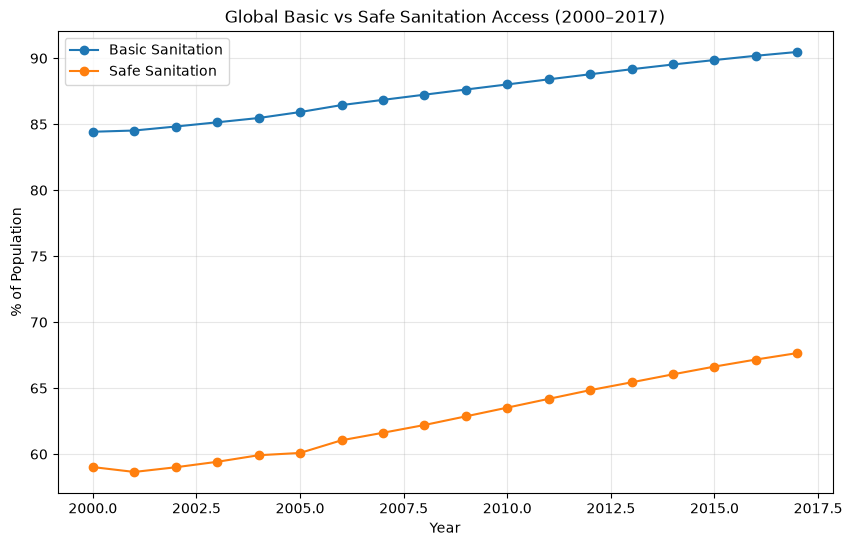

In [4]:
# Cell 3 — Plot Global Basic vs Safe Sanitation Trend

plt.figure(figsize=(10, 6))
plt.plot(global_sani["year"], global_sani["basic_pct"], marker="o", label="Basic Sanitation")
plt.plot(global_sani["year"], global_sani["safe_pct"], marker="o", label="Safe Sanitation")
plt.xlabel("Year")
plt.ylabel("% of Population")
plt.title("Global Basic vs Safe Sanitation Access (2000–2017)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

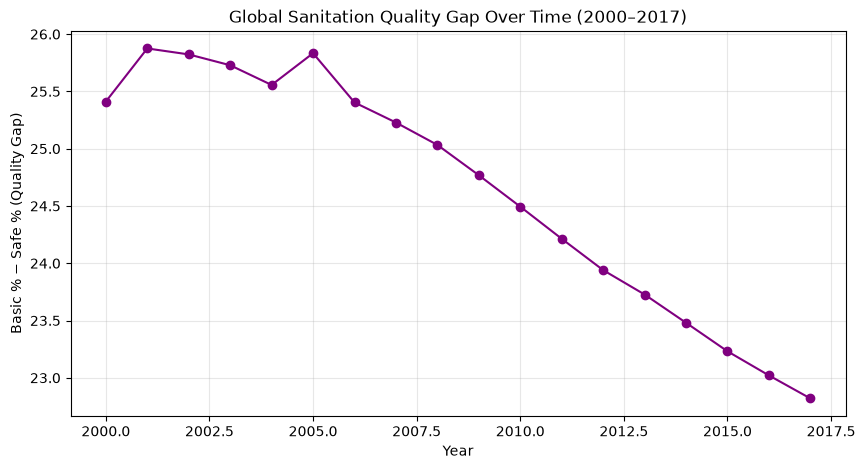

Gap in 2000: 25.41
Gap in 2017: 22.82


In [5]:
# Cell 4 — Has the Quality Gap Closed or Widened?

plt.figure(figsize=(10, 5))
plt.plot(global_sani["year"], global_sani["quality_gap"], marker="o", color="purple")
plt.xlabel("Year")
plt.ylabel("Basic % − Safe % (Quality Gap)")
plt.title("Global Sanitation Quality Gap Over Time (2000–2017)")
plt.grid(alpha=0.3)
plt.show()

print(f"Gap in {global_sani['year'].min()}: {global_sani['quality_gap'].iloc[0]:.2f}")
print(f"Gap in {global_sani['year'].max()}: {global_sani['quality_gap'].iloc[-1]:.2f}")

In [6]:
# Cell 5 — Average Basic/Safe/Gap Per Country (2000–2017)

country_avg = q13.groupby("country")[["basic_pct", "safe_pct", "quality_gap"]].mean().reset_index()
country_avg.head()

,country,basic_pct,safe_pct,quality_gap
0,Albania,94.110000,38.699444,55.410556
1,Algeria,86.030000,18.130556,67.899444
2,Andorra,100.000000,69.412778,30.587222
3,Armenia,90.343333,47.991667,42.351667
4,Australia,99.990000,68.655556,31.334444


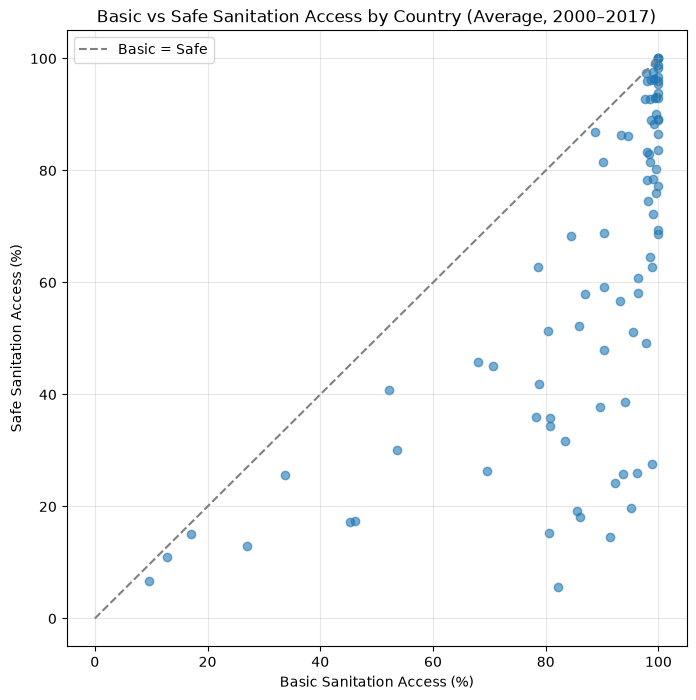

In [7]:
# Cell 6 — Scatter: Basic vs Safe Sanitation Access (Average, 2000–2017)

plt.figure(figsize=(8, 8))
plt.scatter(country_avg["basic_pct"], country_avg["safe_pct"], alpha=0.6)
plt.plot([0, 100], [0, 100], linestyle="--", color="gray", label="Basic = Safe")
plt.xlabel("Basic Sanitation Access (%)")
plt.ylabel("Safe Sanitation Access (%)")
plt.title("Basic vs Safe Sanitation Access by Country (Average, 2000–2017)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
# Cell 7 — Top 10 Countries in the "High Basic, Low Safe" Quadrant

basic_median = country_avg["basic_pct"].median()

high_basic_low_safe = country_avg[country_avg["basic_pct"] >= basic_median].sort_values(
    "quality_gap", ascending=False
).head(10)

high_basic_low_safe[["country", "basic_pct", "safe_pct", "quality_gap"]]

,country,basic_pct,safe_pct,quality_gap
43,Libya,98.790556,27.623889,71.166667
66,Samoa,97.787222,49.254444,48.532778
32,Iceland,98.787222,62.739444,36.047778
61,Portugal,98.548333,64.613333,33.935000
4,Australia,99.990000,68.655556,31.334444
2,Andorra,100.000000,69.412778,30.587222
68,Saudi Arabia,99.122222,72.241667,26.880556
19,Cyprus,99.567778,75.972778,23.595000
56,Norway,98.063889,74.618333,23.445556
67,San Marino,100.000000,77.230000,22.770000


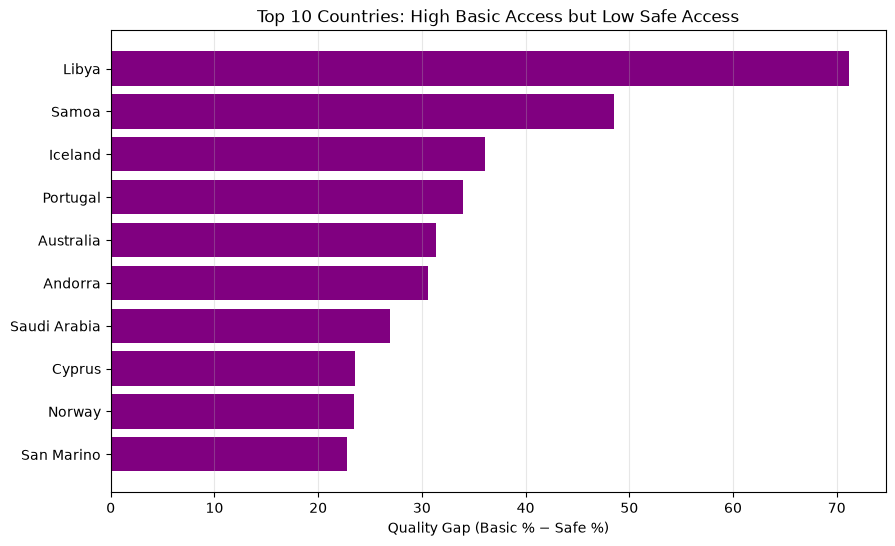

In [9]:
# Cell 8 — Plot Top 10 Countries: High Basic Access but Low Safe Access

plt.figure(figsize=(10, 6))
plt.barh(high_basic_low_safe["country"], high_basic_low_safe["quality_gap"], color="purple")
plt.xlabel("Quality Gap (Basic % − Safe %)")
plt.title("Top 10 Countries: High Basic Access but Low Safe Access")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

In [10]:
# Cell 9 — Urban vs Rural Quality Gap Comparison

ur_avg = q13_ur.groupby("dim1")[["basic_pct", "safe_pct", "quality_gap"]].mean().reset_index()
ur_avg

,dim1,basic_pct,safe_pct,quality_gap
0,Rural,69.625939,54.222771,15.403167
1,Urban,88.051837,59.952275,28.099562


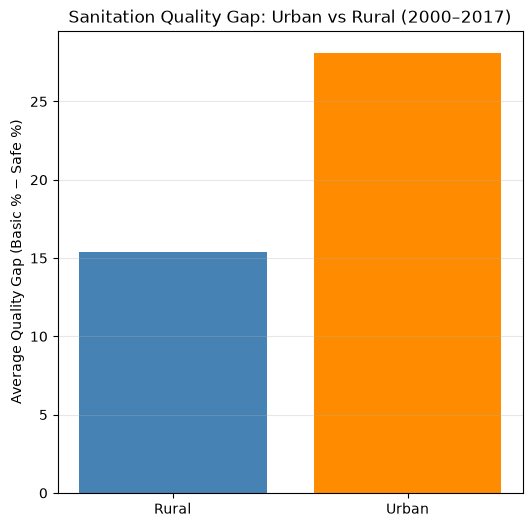

In [11]:
# Cell 10 — Plot Urban vs Rural Quality Gap

plt.figure(figsize=(6, 6))
plt.bar(ur_avg["dim1"], ur_avg["quality_gap"], color=["steelblue", "darkorange"])
plt.ylabel("Average Quality Gap (Basic % − Safe %)")
plt.title("Sanitation Quality Gap: Urban vs Rural (2000–2017)")
plt.grid(axis="y", alpha=0.3)
plt.show()